# Сверточные нейронные сети

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

import torchvision
import torchvision.transforms.v2 as T

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib import cm
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

## Поучим че-нибудь сверточное

### Подготовка данных

In [3]:
%cd /home/jovyan/bspanfilov/dl_seminars/04/

/home/jovyan/bspanfilov/dl_seminars/04


In [4]:
# !kaggle datasets download -d lantian773030/pokemonclassification
# !unzip -qq archive.zip

In [5]:
!ls -la PokemonData/ | head

total 1132
drwxr-xr-x 152 jovyan jovyan 16384 Nov  7 19:54 .
drwxr-xr-x   3 jovyan jovyan  4096 Nov 12 22:21 ..
drwxr-xr-x   2 jovyan jovyan  4096 Nov  7 16:35 Abra
drwxr-xr-x   2 jovyan jovyan  4096 Nov  7 16:35 Aerodactyl
drwxr-xr-x   2 jovyan jovyan  4096 Nov  7 16:35 Alakazam
drwxr-xr-x   2 jovyan jovyan  4096 Nov  7 16:35 Alolan Sandslash
drwxr-xr-x   2 jovyan jovyan  8192 Nov  7 16:35 Arbok
drwxr-xr-x   2 jovyan jovyan  8192 Nov  7 16:35 Arcanine
drwxr-xr-x   2 jovyan jovyan  8192 Nov  7 16:35 Articuno
ls: write error: Broken pipe


In [6]:
import glob

bad_images = glob.glob("PokemonData/*/*.svg")

In [7]:
import os
for bad_image in bad_images:
    os.remove(bad_image)

In [8]:
class PokemonDataset(Dataset):
    SPLIT_RANDOM_SEED = 42
    TEST_SIZE = 0.25

    def __init__(self, root, train=True, load_to_ram=True, transform=None):
        super().__init__()
        self.root = root
        self.train = train
        self.load_to_ram = load_to_ram
        self.transform = transform
        self.all_files = []
        self.all_labels = []
        self.images = []

        self.classes = sorted(os.listdir(self.root))
        for i, class_name in tqdm(enumerate(self.classes), total=len(self.classes)):
            files = sorted(os.listdir(os.path.join(self.root, class_name)))
            train_files, test_files = train_test_split(files, random_state=self.SPLIT_RANDOM_SEED + i,
                                                       test_size=self.TEST_SIZE)
            if self.train:
                self.all_files += train_files
                self.all_labels += [i] * len(train_files)
                if self.load_to_ram:
                    self.images += self._load_images(train_files, i)

            else:
                self.all_files += test_files
                self.all_labels += [i] * len(test_files)
                if self.load_to_ram:
                    self.images += self._load_images(test_files, i)

    def _load_images(self, image_files, label):
        images = []
        for filename in image_files:
            image = torchvision.io.read_image(os.path.join(self.root, self.classes[label], filename)) / 255.0
            images += [image]

        return images

    def __len__(self):
        return len(self.all_files)

    def try__getitem__(self, item):
        label = self.all_labels[item]
        if self.load_to_ram:
            image = self.images[item]
        else:
            filename = self.all_files[item]
            image = torchvision.io.read_image(os.path.join(self.root, self.classes[label], filename)) / 255.0

        return image, label

    def __getitem__(self, item):
        try:
            image, label = self.try__getitem__(item)
            assert image.shape[0] == 3, image

            if self.transform is not None:
                image = self.transform(image)
        except Exception as e:
            return self.__getitem__(item + 1)
        
        return image, label

In [9]:
train_dataset = PokemonDataset(root='PokemonData', train=True, load_to_ram=False)

100%|██████████| 150/150 [00:00<00:00, 2157.99it/s]


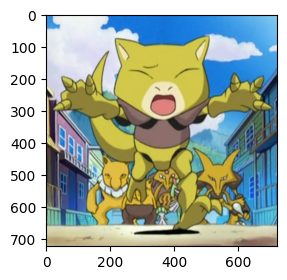

In [14]:
image, label = train_dataset[10]

plt.figure(figsize=(3, 3))
plt.imshow(image.permute(1, 2, 0))
plt.show()

In [15]:
train_dataset.classes[label]

'Abra'

In [16]:
normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

test_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    normalize,
])

In [17]:
train_dataset = PokemonDataset(root='PokemonData', train=True, load_to_ram=True, transform=test_transform)
test_dataset = PokemonDataset(root='PokemonData', train=False, load_to_ram=True, transform=test_transform)

 68%|██████▊   | 102/150 [00:20<00:08,  5.85it/s]libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
100%|██████████| 150/150 [00:11<00:00, 12.90it/s]


In [18]:
print(f'Число классов: {len(train_dataset.classes)}')

Число классов: 150


In [19]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True, num_workers=2)

In [20]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.notebook import tqdm


sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 15})


def plot_losses(train_losses, test_losses, train_accuracies, test_accuracies):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_accuracies) + 1), train_accuracies, label='train')
    axs[1].plot(range(1, len(test_accuracies) + 1), test_accuracies, label='test')
    axs[1].set_ylabel('accuracy')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [22]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    train_loss, train_accuracy = 0.0, 0.0
    model.train()
    for images, labels in tqdm(train_loader, desc=tqdm_desc):
        images = images.to(device)  # images: batch_size x num_channels x height x width
        labels = labels.to(device)  # labels: batch_size

        optimizer.zero_grad()
        logits = model(images)  # logits: batch_size x num_classes
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.shape[0]
        train_accuracy += (logits.argmax(dim=1) == labels).sum().item()

    train_loss /= len(train_loader.dataset)
    train_accuracy /= len(train_loader.dataset)
    return train_loss, train_accuracy


@torch.no_grad()
def validation_epoch(model, criterion, test_loader, tqdm_desc):
    test_loss, test_accuracy = 0.0, 0.0
    model.eval()
    for images, labels in tqdm(test_loader, desc=tqdm_desc):
        images = images.to(device)  # images: batch_size x num_channels x height x width
        labels = labels.to(device)  # labels: batch_size
        logits = model(images)  # logits: batch_size x num_classes
        loss = criterion(logits, labels)

        test_loss += loss.item() * images.shape[0]
        test_accuracy += (logits.argmax(dim=1) == labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy /= len(test_loader.dataset)
    return test_loss, test_accuracy


def train(model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs):
    train_losses, train_accuracies = [], []
    test_losses, test_accuracies = [], []

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        test_loss, test_accuracy = validation_epoch(
            model, criterion, test_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if scheduler is not None:
            scheduler.step()

        train_losses += [train_loss]
        train_accuracies += [train_accuracy]
        test_losses += [test_loss]
        test_accuracies += [test_accuracy]
        plot_losses(train_losses, test_losses, train_accuracies, test_accuracies)

    return train_losses, test_losses, train_accuracies, test_accuracies

### Модель из линейных слоев

In [23]:
import torch.nn as nn
import torch.nn.functional as F

class LinearNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 3 * 889 * 1200
        self.pooling = nn.AvgPool2d(kernel_size=12)
        self.lin1 = nn.Linear(972, 1024)
        self.lin2 = nn.Linear(1024, 512)
        self.lin3 = nn.Linear(512, len(train_dataset.classes))

        self.relu = nn.ReLU()

    def forward(self, x):
        # x.shape = [bs, 3, 889, 1200]
        x = self.relu(self.pooling(x))
        x = x.view(x.size(0), -1)

        x = self.relu(self.lin1(x))
        x = self.relu(self.lin2(x))
        x = self.lin3(x)

        return x

In [25]:
model = LinearNet().to(device)
num_epochs = 10
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

In [26]:
sum(param.numel() for param in model.parameters())


1598102

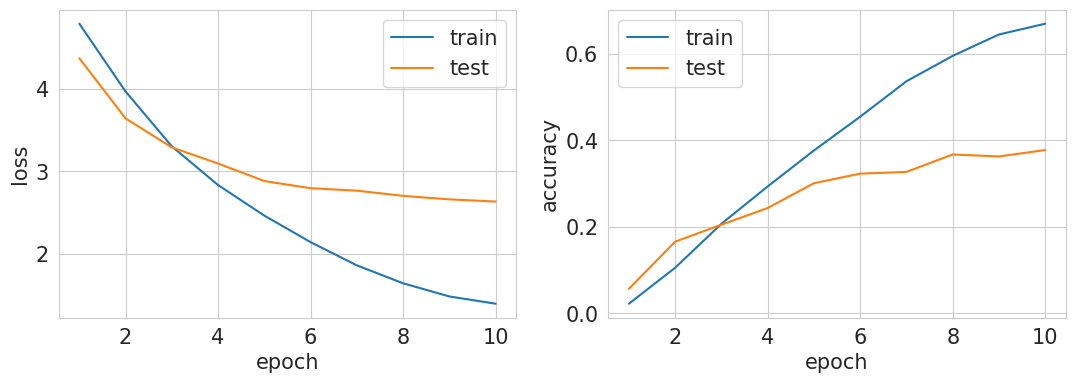

In [27]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [28]:
print("final test accuracy:", test_accuracies[-1])


final test accuracy: 0.37741203178206584


### Сверточная модель

In [29]:
import torch.nn as nn
import torch.nn.functional as F

class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.AvgPool2d(kernel_size=28)
        self.linear = nn.Linear(2048, len(train_dataset.classes))

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))

        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.linear(x)

        return x

In [30]:
model = ConvNet().to(device)
num_epochs = 10
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

In [31]:
sum(param.numel() for param in model.parameters())

312534

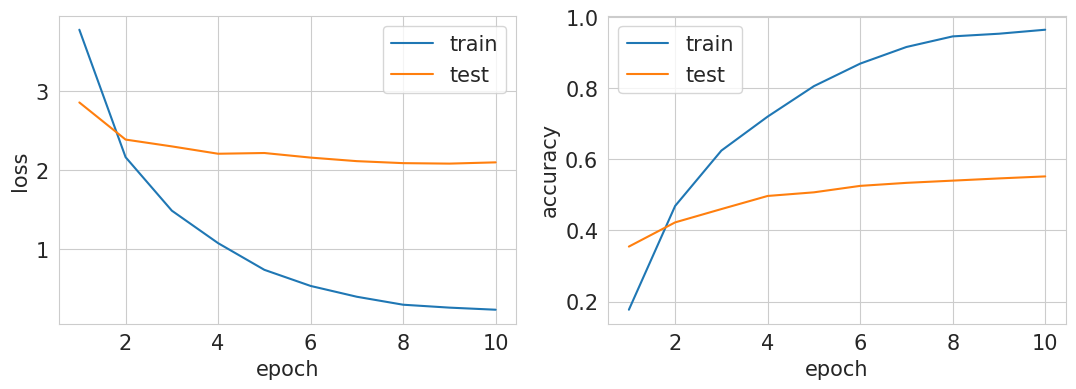

In [37]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [38]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.5522133938706016


### Готовая архитектура

In [32]:
from torchvision.models import resnet18

num_epochs = 10
model = resnet18(num_classes=len(train_dataset.classes)).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

In [33]:
sum(param.numel() for param in model.parameters())

11253462

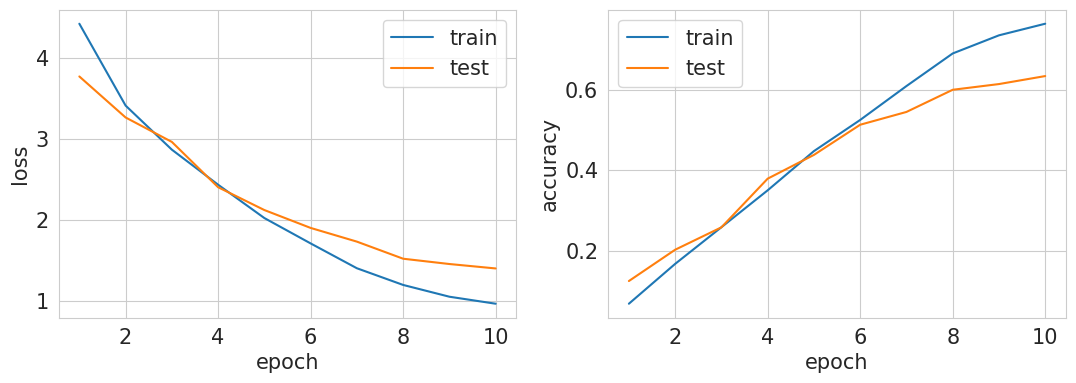

In [41]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [42]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.6333711691259932


### Добавляем аугментации

In [23]:
train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    normalize,
])

In [24]:
train_dataset.transform = train_transform
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, num_workers=2)

In [26]:
model = resnet18(num_classes=len(train_dataset.classes)).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

In [27]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

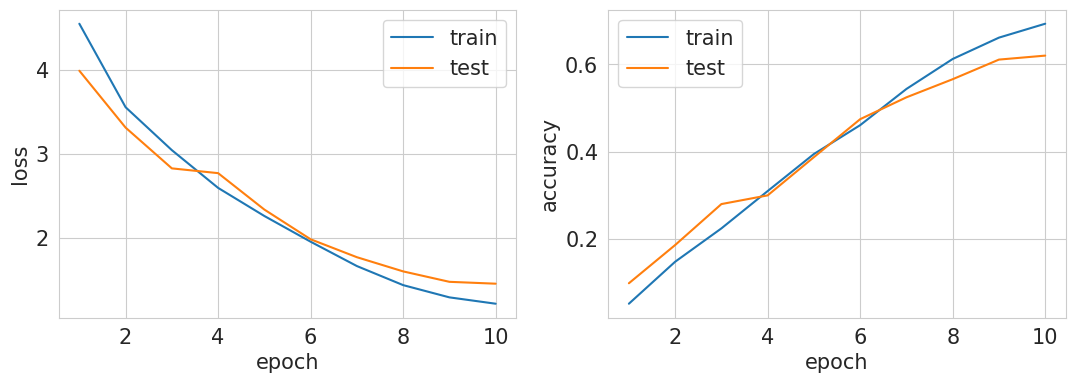

In [28]:
num_epochs = 10
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [48]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.6242905788876277


### Finetune

In [49]:
model = resnet18(pretrained=True).to(device)
model.fc = torch.nn.Linear(512, len(train_dataset.classes))
model = model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 36.6MB/s]


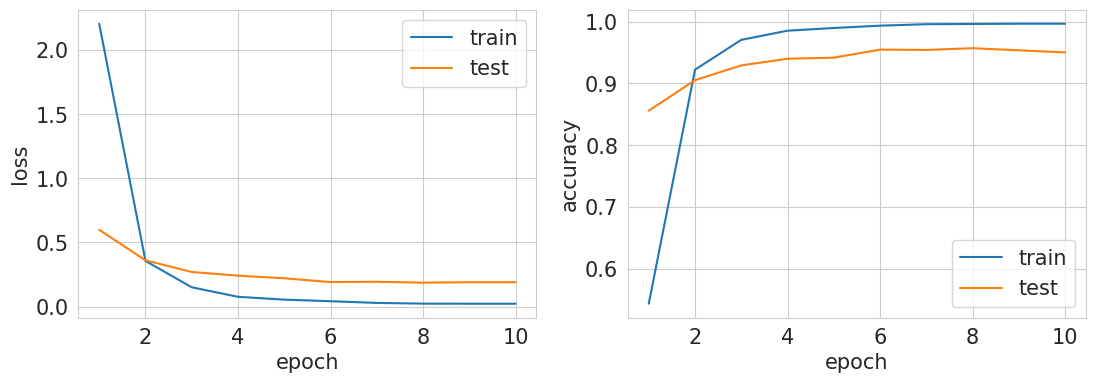

In [50]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [51]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.9500567536889898


### Linear Probing

In [52]:
model = resnet18(pretrained=True).to(device)
model.fc = torch.nn.Linear(512, len(train_dataset.classes))
model = model.to(device)

for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.SGD([param for param in model.parameters() if param.requires_grad], lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

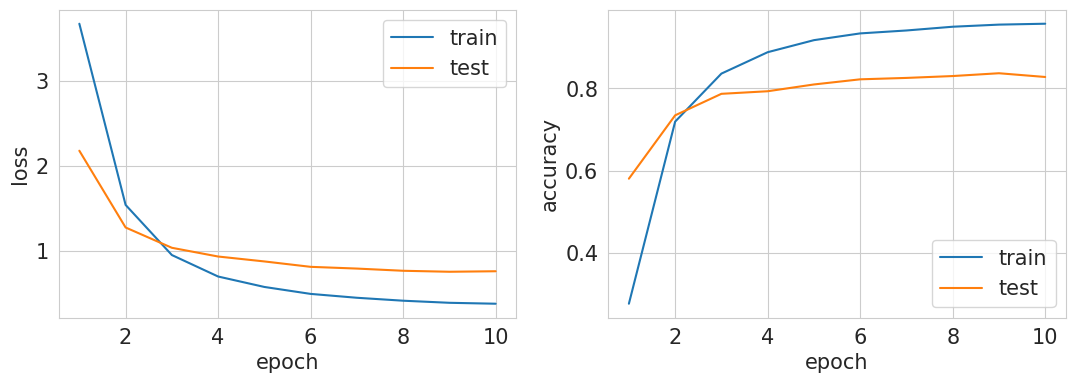

In [53]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [54]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.8274687854710556


### На одном резнете мир не заканчивается

In [29]:
from torchvision.models import wide_resnet50_2

num_epochs = 10
model = wide_resnet50_2(num_classes=len(train_dataset.classes)).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

In [30]:
sum(param.numel() for param in model.parameters())

67141590

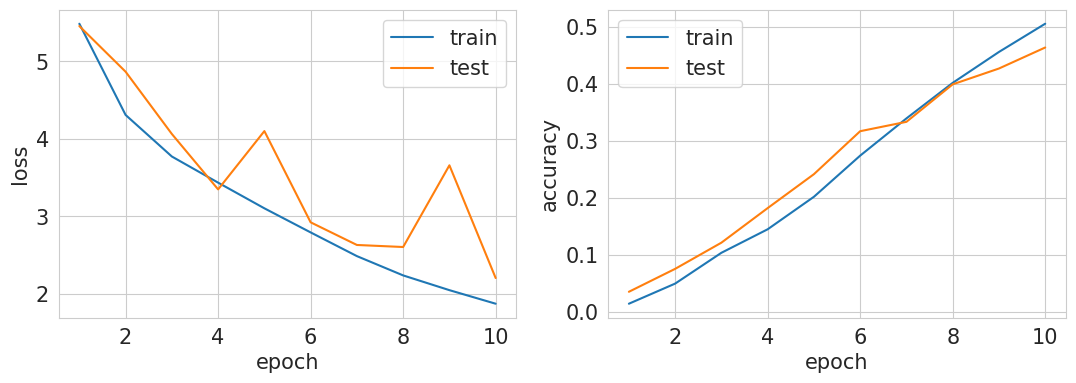

In [31]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [32]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.4642451759364359


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), strid

### Finetune

In [36]:
model = wide_resnet50_2(pretrained=True).to(device)
model.fc = torch.nn.Linear(2048, len(train_dataset.classes))
model = model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

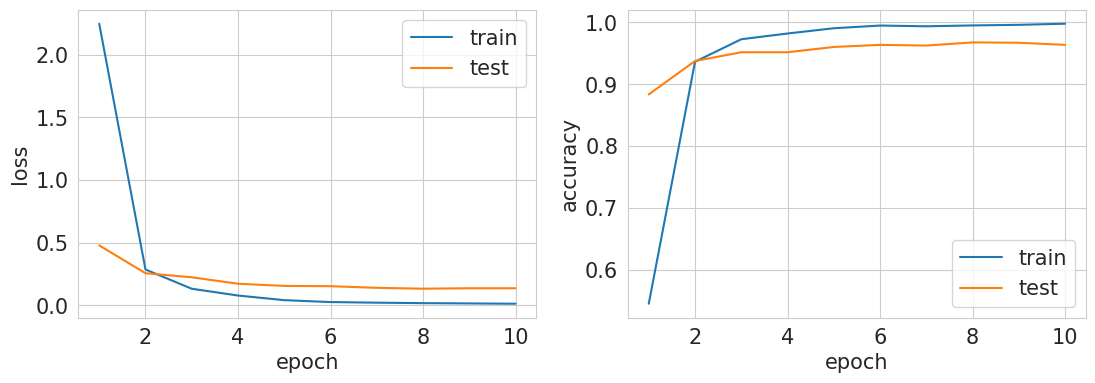

In [37]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [38]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.963677639046538


### Про бдз1

базовый минимум или роскошный максимум

Соревнование - решаем всем потоком задачу классификации. По итогам соревнования пишем отчет о том, что попробовали.

0. смотрим на данные (Размер датасета, Распределение классов, Качество изображений)

1. пишем код локально

1.1 Dataset

* __len__ и __getitem__

* Обработка изображений: открытие, нормализация, конвертация

1.2 Dataloader

* batch_size, shuffle, num_workers

* collate_fn если нужно

1.3 аугментации

* вспоминаем все, что пробовали во 2 домашке, и, что обсуждали на нисе. Балансируем, чтобы не слишком сильно регуляризовывать обучение

1.4 Модель

* начинаем с какого-нибудь бейзлайна, потом усложняем/берем какие-то более сложные архитектуры. Опять же балансируем, чтобы небыло сильного переобучения под трейн

1.5 логгирование, Чем больше всего залогируете тем проще потом дебажится/оценивать результаты

* лосс

* метрики

* сами картинки и предсказания модели на них

* лр 

* нормы градиентов

* smth else

а еще ассистенты будут карать за отчеты без графиков


1.6 трейн луп/ эвал луп

* тут все базово, не забываем model.eval, with torch.no_grad()

2. дебажим код локально

2.1 Если модель сложная, то сначала пытаемся увидеть что она способна переобучится на одном баче. Как будто не наш случай, но можете попробовать на всякий.

3. переливаем код на каггл (как по мне удобнее всего через гитхаб, git add . && git commit -m "smth" && git push; git pull)

4. Проводим полезные эксперименты. Делаем одно изменение за раз.

5. Дз не про какой-то секрет, использование которого поможет вам выиграть в соревновании, а про то чтобы провести много экспериментов и сделать нормальные выводы. Если человек выше вас в табличке значит он тупо больше разного успел попробовать, а не нашел идеальнейший лр.

6. экскурс к коллаб



